# Causal Relationship Discovery

## 1. Setup and Data Preparation
This section imports necessary libraries and custom functions for data preprocessing, plotting, causal discovery, and evaluation.


In [1]:
import pandas as pd
import numpy as np
import time

print([np.__version__, pd.__version__])
np.set_printoptions(precision=3, suppress=True)


from src.data_preprocessing import preprocess_data
from src.plotting import plot_time_series, plot_heatmap, plot_causal_graph
from src.causal_matrix_evaluation import evaluate_causal_matrices, interpret_evaluation_metrics
from src.run_causal_discovery import run_pcmci, run_varlingam, run_pcmci, run_vcdf_varlingam, run_vcdf_pcmci, run_tcdf, run_dynotears

['1.23.5', '1.5.3']


## 2. Causal Discovery Algorithms and Execution
Here we introduce and execute our causal discovery algorithms to get the correlation matrices and visualise the results.



1. Loading, plotting, and preprocessing data...
Dataset shape: (2000, 15)


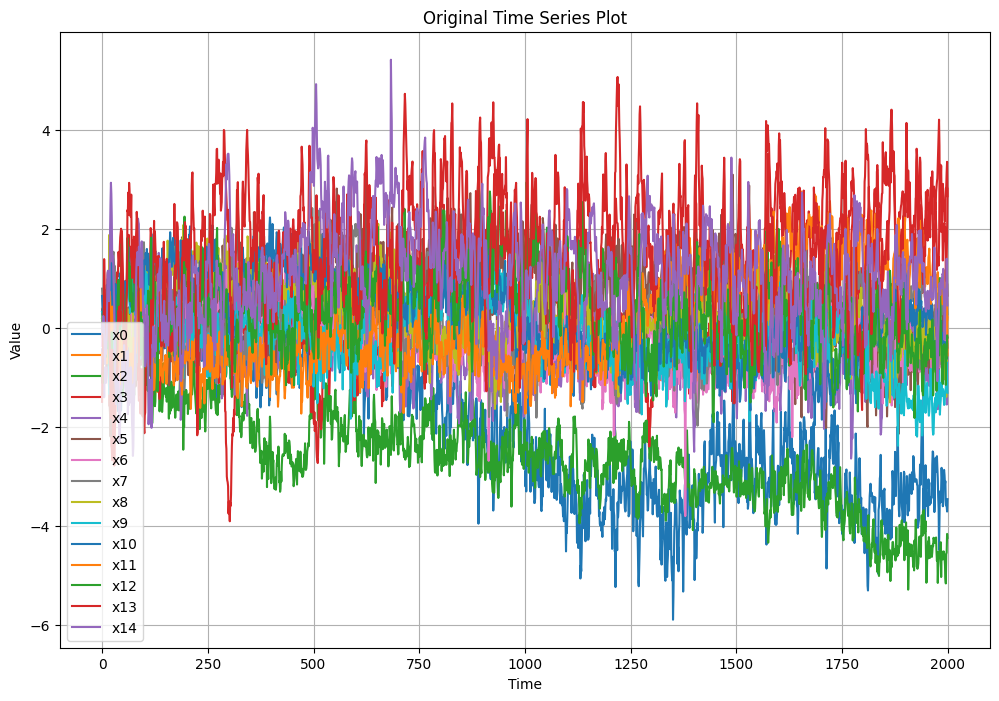


2. Running causal discovery method...

##
## Step 1: PC1 algorithm for selecting lagged conditions
##

Parameters:
independence test = par_corr
tau_min = 1
tau_max = 3
pc_alpha = [0.05]
max_conds_dim = None
max_combinations = 1



## Resulting lagged parent (super)sets:

    Variable 0 has 9 link(s):
        (0 -1): max_pval = 0.00000, |min_val| =  0.685
        (5 -1): max_pval = 0.00000, |min_val| =  0.245
        (5 -3): max_pval = 0.00000, |min_val| =  0.162
        (10 -1): max_pval = 0.00000, |min_val| =  0.118
        (2 -2): max_pval = 0.00003, |min_val| =  0.094
        (1 -3): max_pval = 0.00026, |min_val| =  0.082
        (4 -2): max_pval = 0.00090, |min_val| =  0.074
        (0 -3): max_pval = 0.00098, |min_val| =  0.074
        (13 -2): max_pval = 0.04564, |min_val| =  0.045

    Variable 1 has 6 link(s):
        (1 -1): max_pval = 0.00000, |min_val| =  0.601
        (1 -3): max_pval = 0.00000, |min_val| =  0.147
        (0 -1): max_pval = 0.01528, |min_val| =  0.054
    

<Figure size 640x480 with 0 Axes>

In [14]:
# 1. Load, plot, and preprocess data
print("\n1. Loading, plotting, and preprocessing data...")
data = pd.read_csv('data/synthetic/scale_len_2000/dataset_0.csv')
# data = pd.read_csv('data/real/fMRI/returns/timeseries1.csv')
columns = data.columns.tolist()
if "Date" in columns:
    data = data.drop(['Date'], axis=1).values
    columns.remove('Date')
else:
    data = data.values
print("Dataset shape:", data.shape)

# Plot original time series
plot_time_series(data, columns, title="Original Time Series Plot")

# Preprocess data
data = preprocess_data(data, columns)

# 2. Run causal discovery method
print("\n2. Running causal discovery method...")
start_time = time.time()

method = "pcmci"
if method == 'pcmci':
    adjacency_matrices = run_pcmci(data)
elif method == 'vcdf_pcmci':
    adjacency_matrices = run_vcdf_pcmci(data)
elif method == 'varlingam':
    adjacency_matrices = run_varlingam(data)
elif method == 'vcdf_varlingam':
    adjacency_matrices = run_vcdf_varlingam(data)
elif method == 'tcdf':
    adjacency_matrices = run_tcdf(data)
elif method == 'dynotears':
    adjacency_matrices = run_dynotears(data)
else:
    raise ValueError(f"Unknown method: {method}")

end_time = time.time()

# 3. Print results and execution time
print("\n3. Printing results...")
print("Adjacency matrices:", adjacency_matrices)
print(f"Execution time: {end_time - start_time} seconds")

# 4. Visualize results
# print("\n4. Visualizing results...")
# plot_heatmap(adjacency_matrices, columns)
# causal_graph = plot_causal_graph(adjacency_matrices, node_labels=columns)
# display(causal_graph)

## 3. Model Evaluation 
This section focuses on evaluating our causal discovery algorithms using frobenius norm, structural hamming distance, and f1-score metrics.


Causal Discovery Evaluation Results:
[Structural Hamming Distance] Poor: 182 (267.65%). Many structural differences.
[f1] Poor: 0.415. Low accuracy in identifying causal relationships.
[F1-Sign] Poor: 0.300. Low accuracy in identifying effect polarities.
[Frobenius Norm] Poor: 2.909. Large discrepancies between true and estimated matrices.
[lags] Overestimation: Estimated 4 lags, with 2 extra lags.

6. Visualizing comparison...


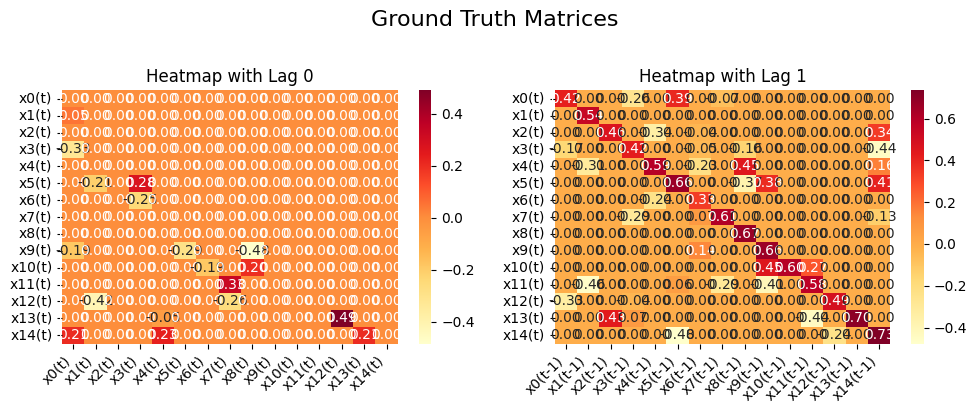

<Figure size 640x480 with 0 Axes>

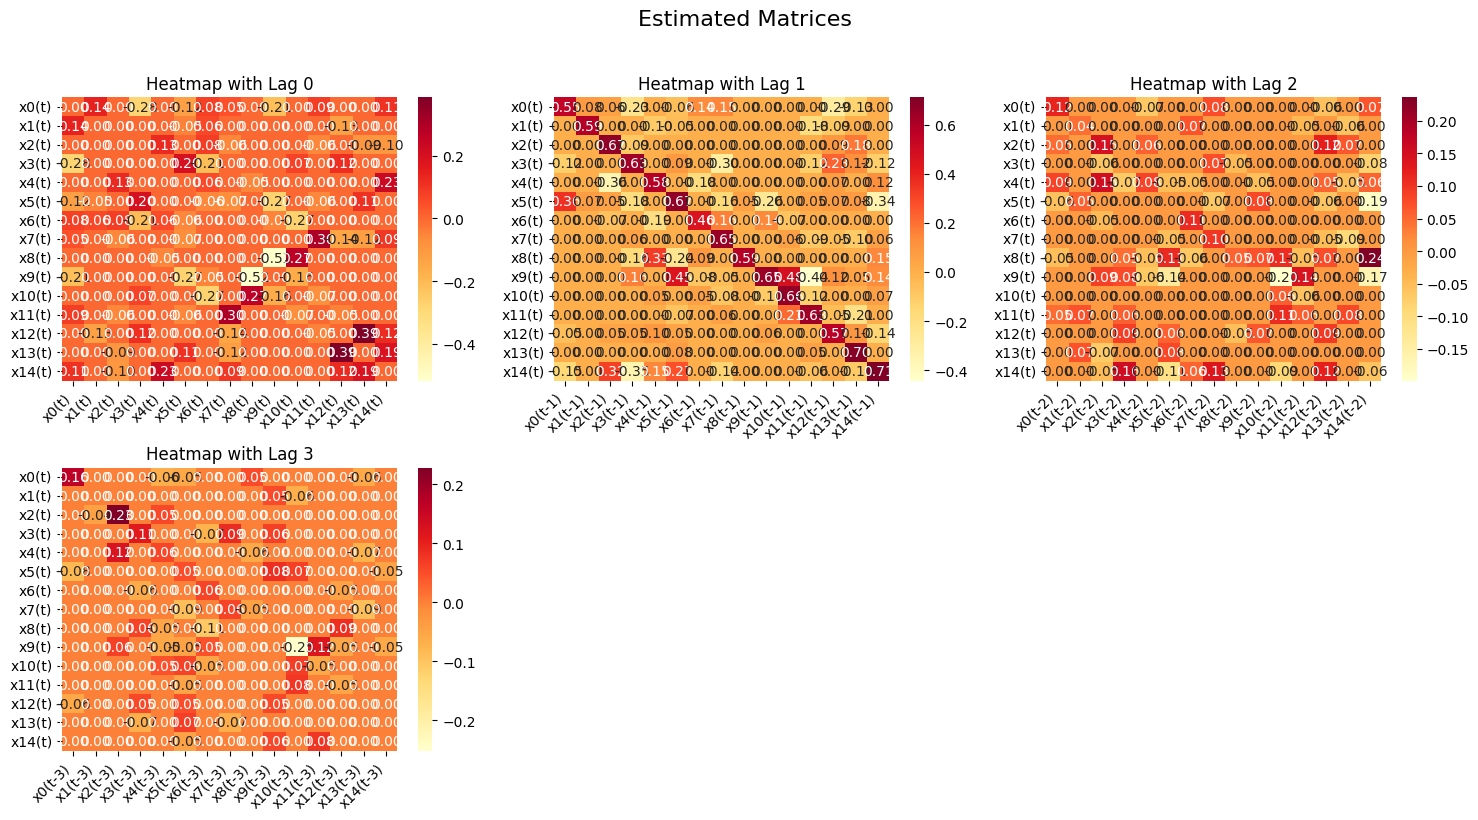

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [15]:
from src.matrix_utils import read_matrices_from_csv

ground_truth_matrices = read_matrices_from_csv('data/synthetic/scale_len_2000/ground_truth.csv')

# Evaluate causal discovery results
print("\nCausal Discovery Evaluation Results:")
evaluation_results = evaluate_causal_matrices(ground_truth_matrices, adjacency_matrices)
result_interpretations = interpret_evaluation_metrics(evaluation_results)

# Print evaluation results
for metric, interpretation in result_interpretations.items():
    print(f"[{metric}] {interpretation}")

# 6. Visualize comparison (optional)
print("\n6. Visualizing comparison...")
plot_heatmap(ground_truth_matrices, columns, title="Ground Truth Matrices")
plot_heatmap(adjacency_matrices, columns, title="Estimated Matrices")

## 4. Evaluation with summary causal graph


Causal Discovery Evaluation Results:
[Structural Hamming Distance] Good: 4 (30.77%). Some structural differences.
[f1] Good: 0.833. Good accuracy in identifying causal relationships.
[F1-Sign] Good: 0.833. Good accuracy in identifying effect polarities.
[Frobenius Norm] Poor: 2.000. Large discrepancies between true and estimated matrices.
[lags] Perfect: Correctly estimated 1 lags.

6. Visualizing comparison...


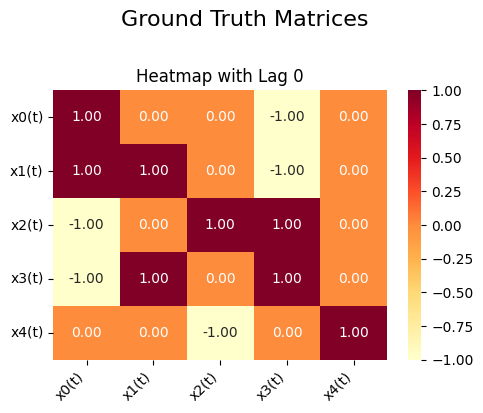

<Figure size 640x480 with 0 Axes>

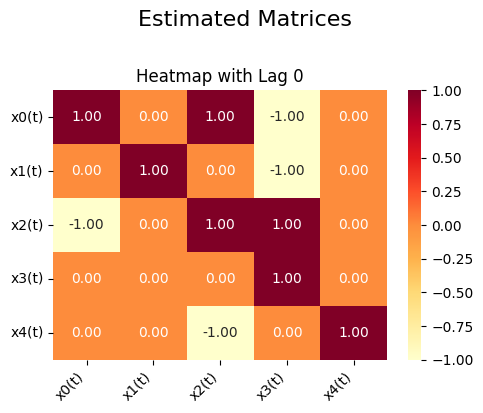

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [6]:
from src.matrix_utils import read_matrices_from_csv, get_summary_matrix

ground_truth_matrices = read_matrices_from_csv('data/synthetic/scale_5_var/ground_truth.csv')

ground_truth_matrices = get_summary_matrix(ground_truth_matrices)
adjacency_matrices = get_summary_matrix(adjacency_matrices)

# Evaluate causal discovery results
print("\nCausal Discovery Evaluation Results:")
evaluation_results = evaluate_causal_matrices([ground_truth_matrices], [adjacency_matrices])
result_interpretations = interpret_evaluation_metrics(evaluation_results)

# Print evaluation results
for metric, interpretation in result_interpretations.items():
    print(f"[{metric}] {interpretation}")

# 6. Visualize comparison (optional)
print("\n6. Visualizing comparison...")
plot_heatmap([ground_truth_matrices], columns, title="Ground Truth Matrices")
plot_heatmap([adjacency_matrices], columns, title="Estimated Matrices")